In [7]:
from dotenv import load_dotenv

load_dotenv("c:/WIP/deep-research-lab/.env")

True

In [1]:
import sys
sys.path.append("c:/WIP/deep-research-lab")

from graph import builder
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

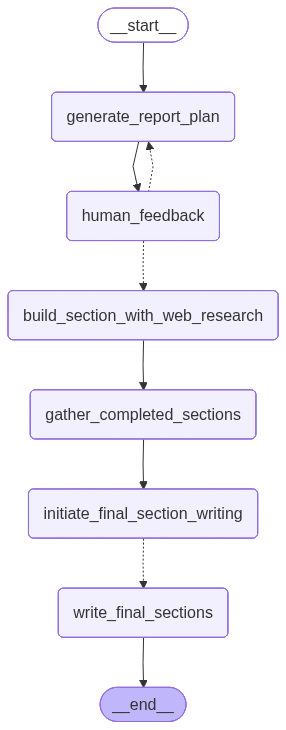

In [2]:
graph

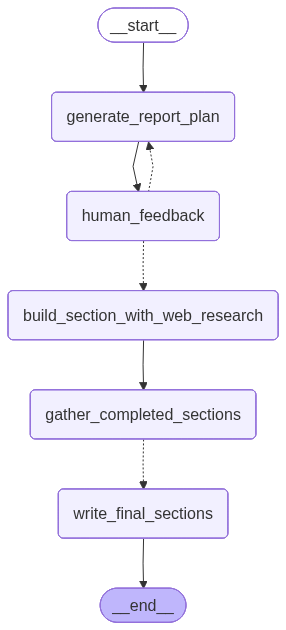

In [2]:
graph

In [ ]:
from IPython.display import display, Markdown
import uuid 

thread = {"configurable": {
                            "thread_id": str(uuid.uuid4()), #  Checkpoint를 위한 고유 스레드 ID 생성
                           "search_api": "tavily",
                           }}


topic = "인공지능에 대해서 조사."

# Run the graph workflow until first interruption (waiting for user feedback)
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

### **함수 테스트용**

In [17]:
import sys
sys.path.append("c:/WIP/deep-research-lab")

from IPython.display import display, Markdown
from state import SectionState, Section, SearchQuery
from config import Configuration
from graph import generate_queries, search_web, write_section
from rich import print
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich import box
from utils import get_search_params

### **Web_search 테스트**

In [ ]:
# 테스트용 섹션 생성
test_section = Section(
    name="딥러닝 기초",
    description="딥러닝의 기본 개념과 신경망 구조에 대한 설명",
    research=True,
    content=""
)

# 테스트용 상태
test_state = {
    "topic": "인공지능에 대해서 조사",
    "section": test_section,
    "search_iterations": 0,
    "search_queries": [
        SearchQuery(search_query="딥러닝 기본 개념"),
        SearchQuery(search_query="신경망 구조 종류")
    ],
    "source_str": "",
    "report_sections_from_research": "",
    "completed_sections": []
}

# 테스트용 config
test_config = {"configurable": {"search_api": "tavily",
                                "search_api_config": {
                                    "include_raw_content": False,
                                }
}}


# 실행
result = await search_web(test_state, test_config)

print(result)
display(Markdown(result['source_str']))

In [8]:
import requests 

response = requests.get(
  "https://api.tavily.com/usage",
  headers={"Authorization": "Bearer API_KEY"}
)

response.json()

{'detail': {'error': 'Unauthorized: missing or invalid API key.'}}

### **writer_section 테스트**

In [2]:
test_state: SectionState = {
    "topic": "LangGraph의 주요 기능",
    
    "section": Section(
        name="소개",
        description="LangGraph의 개요와 주요 특징",
        research=True,
        content=""  # 비어있음
    ),
    
    "search_iterations": 1,
    
    "search_queries": [
        SearchQuery(search_query="LangGraph 개요"),
        SearchQuery(search_query="LangGraph 주요 기능")
    ],
    
    "source_str": """Title: LangGraph 공식 문서
URL: https://langchain-ai.github.io/langgraph/
Content: LangGraph는 LLM 애플리케이션을 위한 상태 기반 워크플로우 프레임워크입니다. 
주요 기능으로는 State 관리, 조건부 라우팅, 인간 개입 지원 등이 있습니다.
---
Title: LangGraph 튜토리얼
URL: https://example.com/langgraph-tutorial
Content: LangGraph는 StateGraph를 사용하여 복잡한 에이전트 워크플로우를 구축할 수 있습니다.
각 노드는 상태를 업데이트하고 다음 노드로 라우팅할 수 있습니다.""",
    
    "report_sections_from_research": "",
    
    "completed_sections": []
}

# 테스트용 config
test_config = {"configurable": {"search_api": "tavily",
                                "search_api_config": {
                                    "include_raw_content": False,
                                }
}}

result = await write_section(test_state, test_config)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 평가 결과: pass                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:


completed_sections = [
    Section(
        name="서론",
        description="AI의 역사적 배경",
        research=True,
        content="AI는 1950년대부터 시작되었으며..."
    ),
    Section(
        name="본론 1",
        description="최신 AI 기술",
        research=True,
        content="GPT-4와 Claude는 최신 LLM으로..."
    ),
    Section(
        name="본론 2",
        description="AI의 윤리적 이슈",
        research=True,
        content="AI 윤리는 매우 중요한 주제로..."
    )
]



In [ ]:

for idx, section in enumerate(completed_sections, 1):
    
    format_str = f"""
            {'='*60}
            Section {idx}: {section.name}
            {'='*60}
            
            """
            
    print(format_str)